In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [35]:
np.random.seed(42) # for reproducible results
floatingpoints = np.random.uniform(low=-5, high=5, size=(10, 2))
points = [[np.round(p[0]), np.round(p[1])] for p in floatingpoints ]
points

[[np.float64(-1.0), np.float64(5.0)],
 [np.float64(2.0), np.float64(1.0)],
 [np.float64(-3.0), np.float64(-3.0)],
 [np.float64(-4.0), np.float64(4.0)],
 [np.float64(1.0), np.float64(2.0)],
 [np.float64(-5.0), np.float64(5.0)],
 [np.float64(3.0), np.float64(-3.0)],
 [np.float64(-3.0), np.float64(-3.0)],
 [np.float64(-2.0), np.float64(0.0)],
 [np.float64(-1.0), np.float64(-2.0)]]

In [42]:
def verify_kdtree_implementation():
    # 1. Create 15 random 2D integer points between -10 and 10 (inclusive of low, exclusive of high for randint)
    np.random.seed(42) # for reproducible results
    # We use high=11 in randint to include the value 10 in the possible range [-10, 10]
    points = np.random.randint(low=-5, high=5, size=(10, 2))
    
    # 2. Define a target point (also an integer for consistency)
    target = np.array([1, 2])
    
    # 3. Use scipy KDTree to find the correct nearest neighbor
    tree = KDTree(points)
    distance, index = tree.query(target, k=1)
    nearest_neighbor = points[index]
    
    print(f"Generated 15 integer points:\n{points}")
    print(f"\nTarget integer point: {target}")
    print(f"\nCorrect nearest neighbor (using SciPy): {nearest_neighbor}")
    print(f"Distance to nearest neighbor: {distance:.2f}")
    
    # 4. Plot the results
    plt.figure(figsize=(8, 8))
    plt.scatter(points[:, 0], points[:, 1], c='blue', label='Data Points (Integers)')
    plt.scatter(target[0], target[1], c='red', marker='x', s=100, label='Target Point')
    plt.scatter(nearest_neighbor[0], nearest_neighbor[1], c='green', marker='o', edgecolors='black', s=150, label='Nearest Neighbor')
    plt.plot([target[0], nearest_neighbor[0]], [target[1], nearest_neighbor[1]], 'k--', lw=1, label='Distance line')
    
    # Add coordinates as labels to the points for clarity
    for i, (x, y) in enumerate(points):
        plt.text(x + 0.3, y + 0.3, f'({x}, {y})', fontsize=8)

    plt.xlabel('X coordinate (Integer)')
    plt.ylabel('Y coordinate (Integer)')
    plt.title('KDTree Nearest Neighbor Search Verification (Integers Only)')
    plt.legend()
    plt.grid(True)
    plt.xlim([-6, 6])
    plt.ylim([-6, 6])
    plt.show()


Generated 15 integer points:
[[ 1 -2]
 [ 2 -1]
 [ 1  4]
 [-3  1]
 [ 2 -1]
 [-2  2]
 [ 2 -3]
 [ 0 -1]
 [-4  2]
 [ 0 -4]]

Target integer point: [1 2]

Correct nearest neighbor (using SciPy): [1 4]
Distance to nearest neighbor: 2.00


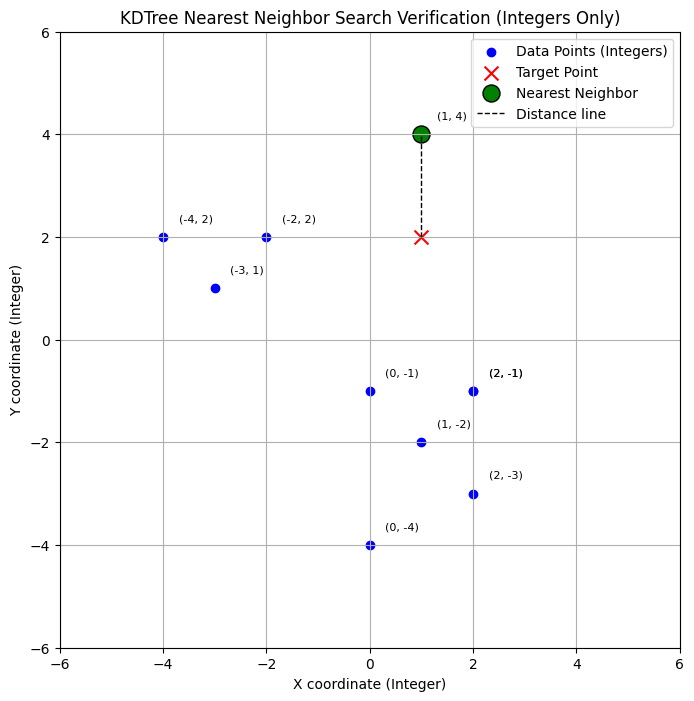

In [43]:
verify_kdtree_implementation()